In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import minimize_scalar



Optimal Hybrid Mix:
  r (fraction of PoW): 0.500
  Security Index: 17.656
  Carbon Footprint per Transaction: 86.865 kWh


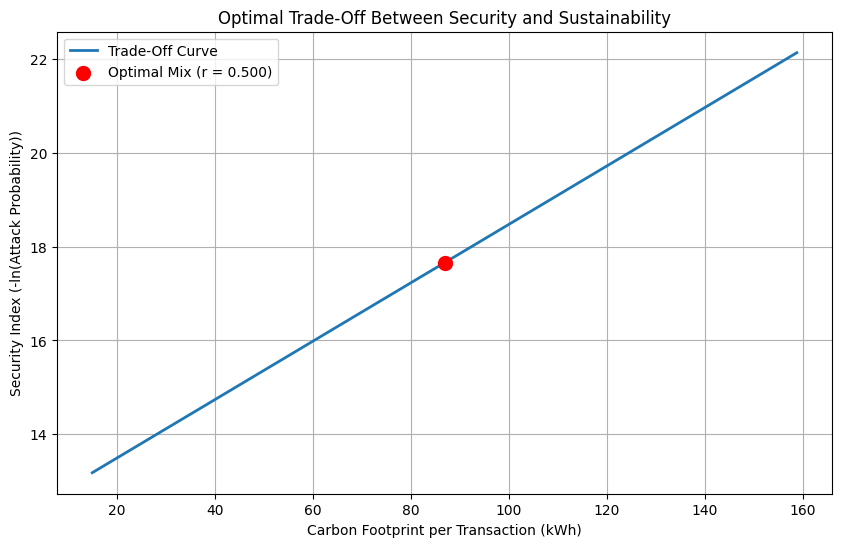

In [2]:

# ----- Security Models -----
def pow_attack_probability(q, z):
    """
    Computes the probability of a successful attack in PoW
    using Nakamoto's Poisson model.
    
    Parameters:
      q (float): Attacker's fraction of hash power.
      z (int): Confirmation depth.
    
    Returns:
      float: Attack success probability.
    """
    if q >= 0.5:
        return 1.0
    p = 1 - q
    lam = z * (q / p)
    attack_prob = 0.0
    for k in range(z):
        attack_prob += poisson.pmf(k, lam) * ((q / p) ** (z - k))
    attack_prob += 1 - poisson.cdf(z - 1, lam)
    return attack_prob

def pos_attack_probability(q, z):
    """
    Computes the probability of a successful attack in PoS
    using a simplified model.
    
    Parameters:
      q (float): Attacker's fraction of stake.
      z (int): Confirmation depth.
      
    Returns:
      float: Attack success probability.
    """
    if q >= 0.5:
        return 1.0
    return (q / (1 - q)) ** z

# ----- Parameters -----

# Confirmation depth (number of blocks)
z = 6

# PoW parameters
A_pow = 1e18      # Attacker's hash rate (hashes/s)
H_pow = 1e20      # Total network hash rate (hashes/s)
q_pow = A_pow / H_pow
P_attack_pow = pow_attack_probability(q_pow, z)
security_index_pow = -np.log(P_attack_pow)  # Higher is better

# PoS parameters
A_pos = 1000.0    # Attacker's available stake (tokens)
S_pos = 10000.0   # Total staked tokens
q_pos = A_pos / S_pos
P_attack_pos = pos_attack_probability(q_pos, z)
security_index_pos = -np.log(P_attack_pos)

# Carbon Footprint per Transaction

# For PoW: estimate energy usage based on hash rate and energy efficiency.
energy_per_hash = 4e-11  # Joules per hash (typical modern ASIC)
seconds_per_day = 86400
# Daily energy consumption in kWh: 
daily_energy_pow = H_pow * energy_per_hash * seconds_per_day / 3.6e6  
# Assume PoW processes 7 transactions per second:
txs_per_day_pow = 7 * seconds_per_day  
carbon_per_tx_pow = daily_energy_pow / txs_per_day_pow  # kWh per transaction

# For PoS, we assume a fixed energy cost per transaction:
carbon_per_tx_pos = 15.0  # kWh per transaction

# ----- Hybrid Model -----

# Hybrid parameter: r = 1 means pure PoW; r = 0 means pure PoS.
def hybrid_security(r):
    """Hybrid security index as weighted average."""
    return r * security_index_pow + (1 - r) * security_index_pos

def hybrid_carbon(r):
    """Hybrid carbon footprint per transaction as weighted average."""
    return r * carbon_per_tx_pow + (1 - r) * carbon_per_tx_pos

# ----- Normalize Objectives and Define Composite Objective -----
# We normalize using the extreme values at r=0 and r=1.
sec_min = min(security_index_pow, security_index_pos)
sec_max = max(security_index_pow, security_index_pos)
carb_min = min(carbon_per_tx_pow, carbon_per_tx_pos)
carb_max = max(carbon_per_tx_pow, carbon_per_tx_pos)

def norm_security(r):
    val = hybrid_security(r)
    return (val - sec_min) / (sec_max - sec_min)

def norm_carbon(r):
    val = hybrid_carbon(r)
    return (val - carb_min) / (carb_max - carb_min)

def composite_objective(r):
    """
    Computes the Euclidean distance from the ideal point in normalized objective space.
    Ideal: normalized security = 1 (max security) and normalized carbon = 0 (min carbon).
    """
    ns = norm_security(r)
    nc = norm_carbon(r)
    return np.sqrt((1 - ns)**2 + (nc - 0)**2)

# ----- Optimization: Find optimal r that minimizes the composite objective -----
res = minimize_scalar(composite_objective, bounds=(0, 1), method='bounded')
r_opt = res.x

# ----- Evaluate Hybrid Metrics at Optimal r -----
optimal_security = hybrid_security(r_opt)
optimal_carbon = hybrid_carbon(r_opt)

print("Optimal Hybrid Mix:")
print("  r (fraction of PoW): {:.3f}".format(r_opt))
print("  Security Index: {:.3f}".format(optimal_security))
print("  Carbon Footprint per Transaction: {:.3f} kWh".format(optimal_carbon))

# ----- Plotting the Trade-Off Curve -----
rs = np.linspace(0, 1, 100)
security_values = [hybrid_security(r) for r in rs]
carbon_values = [hybrid_carbon(r) for r in rs]

plt.figure(figsize=(10, 6))
plt.plot(carbon_values, security_values, label="Trade-Off Curve", lw=2)
plt.scatter([optimal_carbon], [optimal_security], color='red', s=100, zorder=5,
            label="Optimal Mix (r = {:.3f})".format(r_opt))
plt.xlabel("Carbon Footprint per Transaction (kWh)")
plt.ylabel("Security Index (-ln(Attack Probability))")
plt.title("Optimal Trade-Off Between Security and Sustainability")
plt.grid(True)
plt.legend()
plt.show()

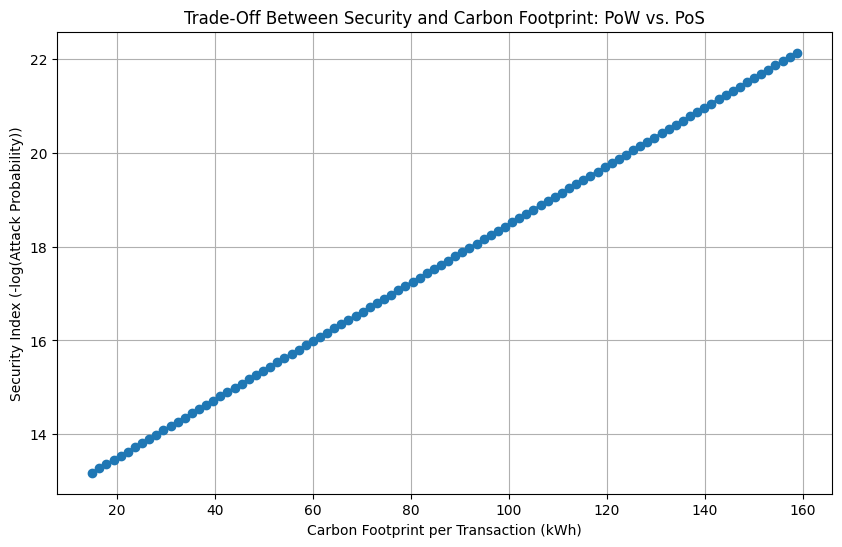

Pure PoW:
  Security Index: 22.13
  Carbon per Transaction: 158.73 kWh
Pure PoS:
  Security Index: 13.18
  Carbon per Transaction: 15.00 kWh


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

def pow_attack_probability(q, z):
    """
    Compute the probability of a successful 51% attack in a PoW system
    using Nakamoto's model (a Poisson process approximation).

    Parameters:
      q (float): Attacker's fraction of total hash power.
      z (int): Confirmation depth (number of blocks behind).
      
    Returns:
      float: Attack success probability.
    """
    # If the attacker controls 50% or more, the attack eventually succeeds.
    if q >= 0.5:
        return 1.0
    
    p = 1 - q
    lam = z * (q / p)
    attack_prob = 0.0
    
    # Sum probability for k = 0 to z-1 blocks found by the attacker.
    for k in range(z):
        attack_prob += poisson.pmf(k, lam) * ((q / p) ** (z - k))
    
    # Add tail probability (attacker finds >= z blocks).
    attack_prob += 1 - poisson.cdf(z - 1, lam)
    return attack_prob

def pos_attack_probability(q, z):
    """
    Compute the probability of a successful attack in a PoS system
    using a simplified gambler's ruin model.
    
    Parameters:
      q (float): Attacker's fraction of the total stake.
      z (int): Confirmation depth (number of blocks behind).
    
    Returns:
      float: Attack success probability.
    """
    if q >= 0.5:
        return 1.0
    return (q / (1 - q)) ** z

# --- Parameters ---

# PoW Parameters
A_pow = 1e18      # Attacker's hash rate in hashes/s (example value)
H_pow = 1e20      # Total network hash rate in hashes/s (example value)
z = 6             # Confirmation depth (number of blocks)
q_pow = A_pow / H_pow  # Attacker's fraction for PoW
P_attack_pow = pow_attack_probability(q_pow, z)
security_index_pow = -np.log(P_attack_pow)  # Higher means more secure

# PoS Parameters
A_pos = 1000.0    # Attacker's available stake (tokens)
S_pos = 10000.0   # Total staked tokens
q_pos = A_pos / S_pos
P_attack_pos = pos_attack_probability(q_pos, z)
security_index_pos = -np.log(P_attack_pos)

# Carbon Footprint per Transaction
# For PoW:
energy_per_hash = 4e-11  # Joules per hash (modern ASIC efficiency)
# Daily energy consumption (kWh) = (H_pow * energy_per_hash * seconds_per_day) / (3.6e6)
seconds_per_day = 86400
daily_energy_pow = H_pow * energy_per_hash * seconds_per_day / 3.6e6  # kWh per day
# Assume PoW throughput is low (e.g., 7 transactions per second)
txs_per_day_pow = 7 * seconds_per_day
carbon_per_tx_pow = daily_energy_pow / txs_per_day_pow

# For PoS:
carbon_per_tx_pos = 15.0  # kWh per transaction (assumed)

# --- Hybrid Trade-Off ---
# Define a range of hybrid ratios (r = 1 means pure PoW, r = 0 means pure PoS)
ratios = np.linspace(0, 1, 100)

# Overall security index and carbon footprint per transaction are combined linearly.
hybrid_security_index = ratios * security_index_pow + (1 - ratios) * security_index_pos
hybrid_carbon = ratios * carbon_per_tx_pow + (1 - ratios) * carbon_per_tx_pos

# --- Plotting the Trade-Off ---
plt.figure(figsize=(10, 6))
plt.plot(hybrid_carbon, hybrid_security_index, marker='o', lw=2)
plt.xlabel("Carbon Footprint per Transaction (kWh)")
plt.ylabel("Security Index (-log(Attack Probability))")
plt.title("Trade-Off Between Security and Carbon Footprint: PoW vs. PoS")
plt.grid(True)
plt.show()

# --- Optional: Plot the pure system values for reference ---
print("Pure PoW:")
print("  Security Index: {:.2f}".format(security_index_pow))
print("  Carbon per Transaction: {:.2f} kWh".format(carbon_per_tx_pow))
print("Pure PoS:")
print("  Security Index: {:.2f}".format(security_index_pos))
print("  Carbon per Transaction: {:.2f} kWh".format(carbon_per_tx_pos))
